# Making an overview figure about TFM data  

Applying for a grant (DOE Genesis 2026). A summary figure of data we have at TFM will be useful. This notebook makes a couple of panels including a map of the mine with geological units and a crossplot of some samples.

In [50]:
# Package imports
import geopandas as gpd # for spatial data handling
import pandas as pd # for tabular data handling
import matplotlib.pyplot as plt # for plotting
import numpy as np # for numerical operations
import rasterio # for reading geotiff files
from shapely.geometry import Point, Polygon, MultiPolygon

In [66]:
# File loading

# base path to data
base_path = '/Users/rmanzuk/Princeton Dropbox/Ryan Manzuk/drc_hyperspectral'

# a planetscope image of the study area
planet_subpath = 'other_sat_ims/tfm_planet_visual/PSScene/20250119_080810_02_24c4_3B_Visual_clip.tif'
planet_path = f'{base_path}/{planet_subpath}'
planet_ds = rasterio.open(planet_path)
planet_img = planet_ds.read() # read the image data into a numpy array

# polygons with local geological outlines
geol_subpath = 'geologic_maps/RMCA_Arc_cuprifere_2008/limite_geol_arc.shp'
geol_path = f'{base_path}/{geol_subpath}'
# we'll save reading the shapefile into a geopandas geodataframe for now

# geolocated geochemical samples    
chem_subpath = 'geochemical_groundtruths/tfm_database_subset.csv'
chem_path = f'{base_path}/{chem_subpath}'
# we'll save reading the csv into a pandas dataframe for now



In [67]:
from shapely.geometry import Point, Polygon, MultiPolygon, LineString, MultiLineString

# Reload the original geometries to avoid converting already-converted data
chem_df = pd.read_csv(chem_path)
chem_gdf = gpd.GeoDataFrame(
    chem_df,
    geometry=gpd.points_from_xy(chem_df.easting, chem_df.northing),
    crs='EPSG:32335'
)
chem_gdf = chem_gdf.to_crs(chem_gdf.crs)

geol_gdf = gpd.read_file(geol_path)
geol_gdf = geol_gdf.to_crs(chem_gdf.crs)


transform = planet_ds.transform


def spatial_to_pixel(x, y, transform):
    """Convert spatial coordinates to pixel coordinates using the geotiff transform."""
    if np.isnan(x) or np.isnan(y):
        return None
    col = int((x - transform[2]) / transform[0])
    row = int((y - transform[5]) / transform[4])
    return col, row


def geometry_to_pixel(geom):
    if geom is None or geom.is_empty:
        return None

    if geom.geom_type == "Point":
        if np.isnan(geom.x) or np.isnan(geom.y):
            return None
        col, row = spatial_to_pixel(geom.x, geom.y, transform)
        return Point(col, row)

    if geom.geom_type == "LineString":
        coords = []
        for x, y in geom.coords:
            pixel = spatial_to_pixel(x, y, transform)
            if pixel is not None:
                coords.append(pixel)
        return LineString(coords) if len(coords) >= 2 else None

    if geom.geom_type == "MultiLineString":
        lines = []
        for line in geom.geoms:
            coords = []
            for x, y in line.coords:
                pixel = spatial_to_pixel(x, y, transform)
                if pixel is not None:
                    coords.append(pixel)
            if len(coords) >= 2:
                lines.append(LineString(coords))
        return MultiLineString(lines) if lines else None

    if geom.geom_type == "Polygon":
        coords = []
        for x, y in geom.exterior.coords:
            pixel = spatial_to_pixel(x, y, transform)
            if pixel is not None:
                coords.append(pixel)
        return Polygon(coords) if len(coords) >= 3 else None

    if geom.geom_type == "MultiPolygon":
        polys = []
        for poly in geom.geoms:
            coords = []
            for x, y in poly.exterior.coords:
                pixel = spatial_to_pixel(x, y, transform)
                if pixel is not None:
                    coords.append(pixel)
            if len(coords) >= 3:
                polys.append(Polygon(coords))
        return MultiPolygon(polys) if polys else None

    # Debug: print what type is falling through
    print(f"Unhandled geometry type: {geom.geom_type}")
    return geom


# Check what geometry types are in the data
print("Geometry types in geol_gdf:")
print(geol_gdf.geometry.geom_type.unique())

print("\nConverting geol_gdf...")
geol_gdf["geometry"] = geol_gdf["geometry"].apply(geometry_to_pixel)
print("Done converting geol_gdf")

print("Converting chem_gdf...")
chem_gdf["geometry"] = chem_gdf["geometry"].apply(geometry_to_pixel)
print("Done converting chem_gdf")

Geometry types in geol_gdf:
['LineString' 'MultiLineString']

Converting geol_gdf...
Done converting geol_gdf
Converting chem_gdf...
Done converting chem_gdf


In [71]:
# search the chem_gdf for the densests cluster of points in a 30x30m area, to find a good area to zoom in on for the figure
# filter out null geometries first
chem_gdf_valid = chem_gdf[chem_gdf.geometry.notnull()].copy()
chem_gdf_valid["x"] = chem_gdf_valid.geometry.x
chem_gdf_valid["y"] = chem_gdf_valid.geometry.y

# create a grid of 30x30m cells and count the number of points in each cell
cell_size = 30
chem_gdf_valid["cell_x"] = (chem_gdf_valid["x"] // cell_size).astype(int)
chem_gdf_valid["cell_y"] = (chem_gdf_valid["y"] // cell_size).astype(int)
cell_counts = chem_gdf_valid.groupby(["cell_x", "cell_y"]).size().reset_index(name="count")

# find the cell with the highest count
max_cell = cell_counts.loc[cell_counts["count"].idxmax()]
print(f"Max cell: {max_cell}")

# isolate the points in that cell
max_cell_points = chem_gdf_valid[
    (chem_gdf_valid["cell_x"] == max_cell["cell_x"]) &
    (chem_gdf_valid["cell_y"] == max_cell["cell_y"])
]
print(f"Number of points in max cell: {len(max_cell_points)}")

Max cell: cell_x    15
cell_y    89
count     64
Name: 45, dtype: int64
Number of points in max cell: 64


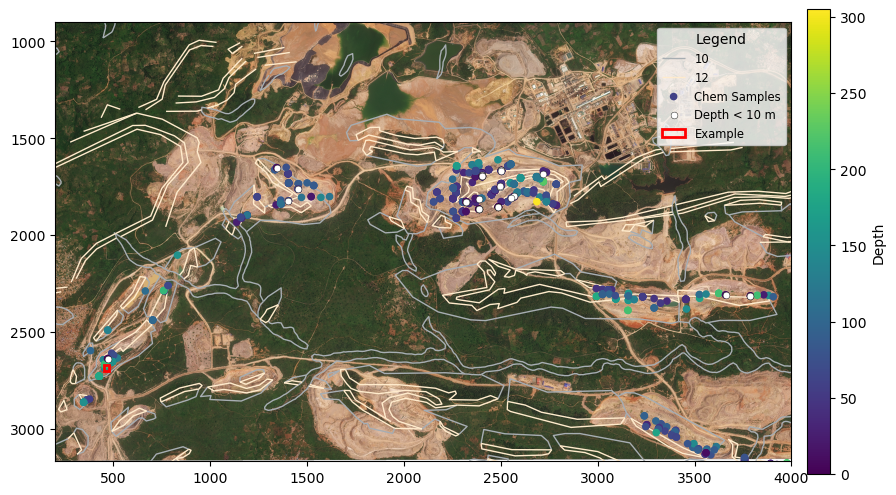

In [ ]:
# make a plot of the image with the geol and chem points overlaid, cropped to rows 900:end and cols 200:4000

# start by showing the cropped image
fig, ax = plt.subplots(figsize=(10, 10))
row_start = 900
col_start = 200
col_end = 4000
img_rgb = np.transpose(planet_img, (1, 2, 0))
img_crop = img_rgb[row_start:, col_start:col_end, :]
ax.imshow(
    img_crop,
    origin="upper",
    extent=(col_start, col_end, planet_ds.height, row_start),
    zorder=0
)

# now add in the geology boundaries, color coded by geologic unit, only plotting POLYDI_IDs 10,11,12
geol_plot = geol_gdf.copy()
valid_units = [10, 12]
geol_plot = geol_plot[geol_plot["POLYDI_ID"].isin(valid_units)]
unit_colors = {10: "#a7adb2", 12: "#FFEBCC",}
for unit, group in geol_plot.groupby("POLYDI_ID"):
    group = group[group.geometry.notnull()]
    if not group.empty:
        group.plot(
            ax=ax,
            facecolor="none",
            edgecolor=unit_colors.get(int(unit), "#ffffff"),
            linewidth=1,
            label=unit,
            zorder=2,
        )

# now add in the chem points, colored by depth (meterage1)
chem_plot = chem_gdf.copy()
chem_plot = chem_plot[chem_plot.geometry.notnull()].copy()
chem_plot = chem_plot[np.isfinite(chem_plot["meterage1"])].copy()

x = chem_plot.geometry.x.values
y = chem_plot.geometry.y.values
depth = chem_plot["meterage1"].values

chem_scatter = ax.scatter(
    x,
    y,
    c=depth,
    cmap="viridis",
    s=20,
    label="Chem Samples",
    zorder=4,
)

# replot shallow samples (<10 m) in white on top
shallow_mask = depth < 10
ax.scatter(
    x[shallow_mask],
    y[shallow_mask],
    c="white",
    s=24,
    edgecolors="black",
    linewidths=0.3,
    label="Surface samples",
    zorder=6,
)

# add a colorbar tied to the depth-colored scatter
cbar = fig.colorbar(chem_scatter, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Depth")

# add the outline of the max cell for reference
cell_x_min = max_cell["cell_x"] * cell_size
cell_y_min = max_cell["cell_y"] * cell_size
rect = plt.Rectangle(
    (cell_x_min, cell_y_min),
    cell_size,
    cell_size,
    edgecolor="red",
    facecolor="none",
    linewidth=2,
    label="Example",
    zorder=5,
)
ax.add_patch(rect)

# add a legend
ax.legend(loc="upper right", fontsize="small", title="Legend")

# clip to requested image window in pixel coordinates
plt.xlim(col_start, col_end)
plt.ylim(planet_ds.height, row_start)
plt.show()

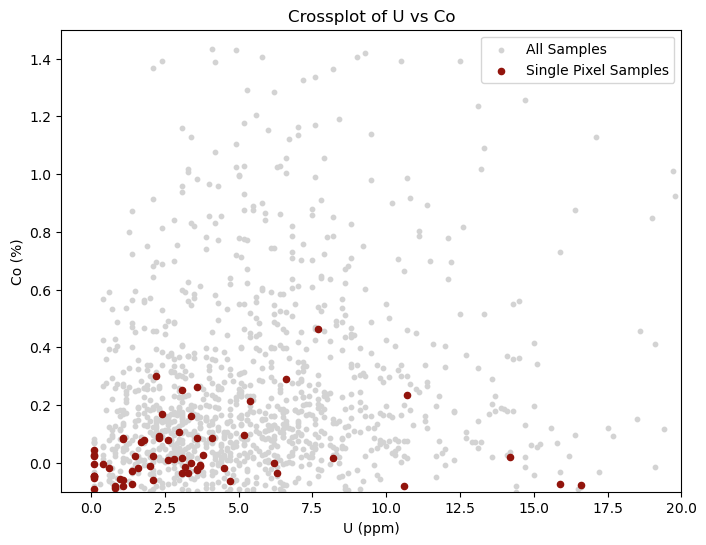

In [ ]:
# crossplot all U and Co values, and then highlight the points in the max cell
fig, ax = plt.subplots(figsize=(8, 6))

# Add small random jitter to cobalt values for plotting only (max magnitude 0.1)
rng = np.random.default_rng(42)
co_all_jittered = chem_gdf["co_pct"].to_numpy() + rng.uniform(-0.1, 0.1, size=len(chem_gdf))
co_max_jittered = max_cell_points["co_pct"].to_numpy() + rng.uniform(-0.1, 0.1, size=len(max_cell_points))

# plot all points
ax.scatter(chem_gdf["u_ppm"], co_all_jittered, color="lightgray", label="All Samples", s=10)

# plot points in max cell
ax.scatter(max_cell_points["u_ppm"], co_max_jittered, color="#92140c", label="Example Pixel Samples", s=20)
ax.set_xlabel("U (ppm)")
ax.set_ylabel("Co (%)")
ax.set_title("Crossplot of U vs Co")
ax.legend()
plt.xlim(-1,20)
plt.ylim(-0.1,1.5)
plt.show()

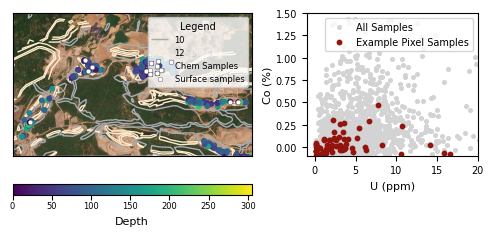

In [126]:
# Combined figure: map (left) + crossplot (right), with map kept at equal aspect.
# Put the colorbar beneath the map to avoid horizontal overlap with crossplot tick labels.
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize=(6, 3))
ax_map = fig.add_subplot(111)

# -------------------------
# Left panel: map
# -------------------------
row_start = 900
col_start = 200
col_end = 4000
img_rgb = np.transpose(planet_img, (1, 2, 0))
img_crop = img_rgb[row_start:, col_start:col_end, :]
ax_map.imshow(
    img_crop,
    origin="upper",
    extent=(col_start, col_end, planet_ds.height, row_start),
    zorder=0,
)

# geology boundaries (match map colors)
geol_plot = geol_gdf.copy()
valid_units = [10, 12]
geol_plot = geol_plot[geol_plot["POLYDI_ID"].isin(valid_units)]
unit_colors = {10: "#a7adb2", 12: "#FFEBCC"}
for unit, group in geol_plot.groupby("POLYDI_ID"):
    group = group[group.geometry.notnull()]
    if not group.empty:
        group.plot(
            ax=ax_map,
            facecolor="none",
            edgecolor=unit_colors.get(int(unit), "#ffffff"),
            linewidth=1,
            label=str(int(unit)),
            zorder=2,
        )

# chem samples on top
chem_plot = chem_gdf[chem_gdf.geometry.notnull()].copy()
chem_plot = chem_plot[np.isfinite(chem_plot["meterage1"])].copy()
x = chem_plot.geometry.x.values
y = chem_plot.geometry.y.values
depth = chem_plot["meterage1"].values

chem_scatter = ax_map.scatter(x, y, c=depth, cmap="viridis", s=10, zorder=4, label="Chem Samples")
shallow_mask = depth < 10
ax_map.scatter(
    x[shallow_mask],
    y[shallow_mask],
    c="white",
    s=12,
    edgecolors="black",
    linewidths=0.2,
    zorder=6,
    label="Surface samples",
)

# Preserve requested map geometry
ax_map.set_xlim(col_start, col_end)
ax_map.set_ylim(planet_ds.height, row_start)
ax_map.set_aspect("equal", adjustable="box")
ax_map.set_xticks([])
ax_map.set_yticks([])

# Build companion axes from map axis: crossplot to the right, colorbar beneath map
divider = make_axes_locatable(ax_map)
ax_xp = divider.append_axes("right", size="71.43%", pad=0.55)
cax = divider.append_axes("bottom", size="8%", pad=0.28)

# horizontal colorbar beneath the map
cbar = fig.colorbar(chem_scatter, cax=cax, orientation="horizontal")
cbar.set_label("Depth", fontsize=8)
cbar.ax.tick_params(labelsize=6, pad=1)

# Deduplicate map legend labels and keep naming consistent with standalone map
map_handles, map_labels = ax_map.get_legend_handles_labels()
seen = set()
uniq_handles = []
uniq_labels = []
for h, l in zip(map_handles, map_labels):
    if l not in seen:
        uniq_handles.append(h)
        uniq_labels.append(l)
        seen.add(l)
ax_map.legend(uniq_handles, uniq_labels, loc="upper right", fontsize=6, title="Legend", title_fontsize=7)

# -------------------------
# Right panel: crossplot
# -------------------------
rng = np.random.default_rng(42)
co_all_jittered = chem_gdf["co_pct"].to_numpy() + rng.uniform(-0.1, 0.1, size=len(chem_gdf))
co_max_jittered = max_cell_points["co_pct"].to_numpy() + rng.uniform(-0.1, 0.1, size=len(max_cell_points))

ax_xp.scatter(chem_gdf["u_ppm"], co_all_jittered, color="lightgray", s=7, label="All Samples")
ax_xp.scatter(max_cell_points["u_ppm"], co_max_jittered, color="#92140c", s=10, label="Example Pixel Samples")
ax_xp.set_xlabel("U (ppm)", fontsize=8)
ax_xp.set_ylabel("Co (%)", fontsize=8, labelpad=2)
ax_xp.set_xlim(-1, 20)
ax_xp.set_ylim(-0.1, 1.5)
ax_xp.tick_params(axis="y", labelsize=7, left=True, right=False)
ax_xp.tick_params(axis="x", labelsize=7)
ax_xp.legend(fontsize=7, loc="upper right")

plt.show()
# save to downloads
fig.savefig("/Users/rmanzuk/Downloads/map_crossplot_figure.pdf", dpi=300, bbox_inches="tight")